In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "productivity"
namex = "Productivity"
d = 11

###knn
graphs = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)
###threshold
graphsz = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


# Standard model results

## Nearest neighbor

In [3]:
graphsinfor = []
for iz in range(len(graphs)):
    
    avg_left_deg, avg_left_pos_deg, avg_left_neg_deg, avg_right_deg, \
    avg_overlap,  avg_pos_overlap, avg_neg_overlap, only_pos, only_neg, \
    empty_adj, unipos  = scripts.analytics.getconnectivity_info(graphs[iz]["edges"], graphs[iz]["labels"])

    graphsinfor.append({
        "Dataset (d)": namex+" ("+ str(d) + ")",
        "kmax": graphs[iz]["k_max"], 
        "n": graphs[iz]['n'],
        "m": graphs[iz]['m'],
        "#+ves": len({t for t, l in graphs[iz]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphs[iz]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_deg,2), 
        "avg LHS+d": round(avg_left_pos_deg,2), 
        "avg LHS-d": round(avg_left_neg_deg,2),   
        "avg RHSd": round(avg_right_deg,2),          
        "avg overlap": round(avg_overlap,2), 
        "avg overlap+": round(avg_pos_overlap,2), 
        "avg overlap-": round(avg_neg_overlap,2), 
        "only+Ns": only_pos,
        "only-Ns": only_neg,
        "emptyNs": empty_adj,
        "uni+": unipos,
        "graphID": iz
    })

randomgraphsinfo = pd.DataFrame(graphsinfor)   
randomgraphsinfo



,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Productivity (11),1,112,32,24,8,1.0,0.69,0.31,3.50,0.04,0.02,0.02,77,35,0,0,0
1,Productivity (11),2,112,44,33,11,2.0,1.46,0.54,5.09,0.14,0.10,0.05,62,11,0,0,1
2,Productivity (11),3,112,45,34,11,3.0,2.29,0.71,7.47,0.29,0.22,0.07,52,0,0,0,2
3,Productivity (11),4,112,46,35,11,4.0,2.95,1.05,9.74,0.49,0.34,0.15,28,0,0,0,3
4,Productivity (11),5,112,48,37,11,5.0,3.67,1.33,11.67,0.74,0.51,0.23,16,0,0,0,4
5,Productivity (11),6,112,48,37,11,6.0,4.40,1.60,14.00,1.03,0.71,0.32,9,0,0,0,5
6,Productivity (11),7,112,48,37,11,7.0,5.18,1.82,16.33,1.35,0.95,0.40,4,0,0,0,6
7,Productivity (11),8,112,48,37,11,8.0,6.02,1.98,18.67,1.73,1.27,0.47,3,0,0,0,7
8,Productivity (11),9,112,48,37,11,9.0,6.86,2.14,21.00,2.14,1.60,0.54,3,0,0,0,8
9,Productivity (11),10,112,48,37,11,10.0,7.64,2.36,23.33,2.61,1.95,0.66,2,0,0,0,9


In [4]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfo))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & kmax & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Productivity & (11) & 1 & 112 & 32 & 24 & 8 & 1.0 & 0.69 & 0.31 & 3.50 & 0.04 & 0.02 & 0.02 & 77 & 35 & 0 & 0 & 0 \\
Productivity & (11) & 2 & 112 & 44 & 33 & 11 & 2.0 & 1.46 & 0.54 & 5.09 & 0.14 & 0.10 & 0.05 & 62 & 11 & 0 & 0 & 1 \\
Productivity & (11) & 3 & 112 & 45 & 34 & 11 & 3.0 & 2.29 & 0.71 & 7.47 & 0.29 & 0.22 & 0.07 & 52 & 0 & 0 & 0 & 2 \\
Productivity & (11) & 4 & 112 & 46 & 35 & 11 & 4.0 & 2.95 & 1.05 & 9.74 & 0.49 & 0.34 & 0.15 & 28 & 0 & 0 & 0 & 3 \\
Productivity & (11) & 5 & 112 & 48 & 37 & 11 & 5.0 & 3.67 & 1.33 & 11.67 & 0.74 & 0.51 & 0.23 & 16 & 0 & 0 & 0 & 4 \\
Productivity & (11) & 6 & 112 & 48 & 37 & 11 & 6.0 & 4.40 & 1.60 & 14.00 & 1.03 & 0.71 & 0.32 & 9 & 0 & 0 & 0 & 5 \\
Productivity & (11) & 7 & 112 & 48 & 37 & 11 &

## Thresholding

In [5]:
graphsinforx = []
for ix in range(len(graphsz)):
    
    avg_left_degx, avg_left_pos_degx, avg_left_neg_degx, avg_right_degx, \
    avg_overlapx, avg_pos_overlapx, avg_neg_overlapx, only_posx, only_negx, \
    empty_adjx, uniposx  = scripts.analytics.getconnectivity_info(graphsz[ix]["edges"], graphsz[ix]["labels"])
        
    graphsinforx.append({
        "Dataset (d)":namex+" ("+ str(d) + ")",
        "r": graphsz[ix]["threshold"], 
        "n": graphsz[ix]['n'],
        "m": graphsz[ix]['m'],
        "#+ves": len({t for t, l in graphsz[ix]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphsz[ix]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_degx,2),  
        "avg LHS+d": round(avg_left_pos_degx,2),  
        "avg LHS-d": round(avg_left_neg_degx,2),   
        "avg RHSd": round(avg_right_degx,2),          
        "avg overlap": round(avg_overlapx,2), 
        "avg overlap+": round(avg_pos_overlapx,2), 
        "avg overlap-": round(avg_neg_overlapx,2), 
        "only+Ns": only_posx,
        "only-Ns": only_negx,
        "emptyNs": empty_adjx,
        "uni+": uniposx,
        "graphID": ix
    })

randomgraphsinfox = pd.DataFrame(graphsinforx)   
randomgraphsinfox


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Productivity (11),4.0,112,50,39,11,20.33,15.99,4.34,45.54,9.07,7.08,1.99,0,1,7,0,0
1,Productivity (11),4.5,112,50,39,11,25.60,19.98,5.62,57.34,14.04,10.83,3.21,0,0,6,0,1
2,Productivity (11),5.0,112,50,39,11,32.12,25.08,7.04,71.94,21.89,17.00,4.89,0,0,6,0,2
3,Productivity (11),5.5,112,50,39,11,38.80,30.34,8.46,86.92,31.33,24.43,6.91,0,0,6,0,3
4,Productivity (11),6.0,112,50,39,11,44.24,34.56,9.68,99.10,39.64,30.96,8.68,0,0,5,1,4
5,Productivity (11),6.5,112,50,39,11,46.70,36.42,10.28,104.60,43.72,34.11,9.62,0,0,5,13,5
6,Productivity (11),7.0,112,50,39,11,47.49,37.04,10.46,106.38,45.16,35.21,9.95,0,0,5,25,6
7,Productivity (11),7.5,112,50,39,11,47.73,37.22,10.51,106.92,45.62,35.57,10.05,0,0,5,35,7
8,Productivity (11),8.0,112,50,39,11,47.77,37.26,10.51,107.00,45.69,35.64,10.05,0,0,5,39,8
9,Productivity (11),8.5,112,50,39,11,47.84,37.30,10.54,107.16,45.80,35.70,10.10,0,0,4,5,9


In [6]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfox))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & r & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Productivity & (11) & 4.0 & 112 & 50 & 39 & 11 & 20.33 & 15.99 & 4.34 & 45.54 & 9.07 & 7.08 & 1.99 & 0 & 1 & 7 & 0 & 0 \\
Productivity & (11) & 4.5 & 112 & 50 & 39 & 11 & 25.60 & 19.98 & 5.62 & 57.34 & 14.04 & 10.83 & 3.21 & 0 & 0 & 6 & 0 & 1 \\
Productivity & (11) & 5.0 & 112 & 50 & 39 & 11 & 32.12 & 25.08 & 7.04 & 71.94 & 21.89 & 17.00 & 4.89 & 0 & 0 & 6 & 0 & 2 \\
Productivity & (11) & 5.5 & 112 & 50 & 39 & 11 & 38.80 & 30.34 & 8.46 & 86.92 & 31.33 & 24.43 & 6.91 & 0 & 0 & 6 & 0 & 3 \\
Productivity & (11) & 6.0 & 112 & 50 & 39 & 11 & 44.24 & 34.56 & 9.68 & 99.10 & 39.64 & 30.96 & 8.68 & 0 & 0 & 5 & 1 & 4 \\
Productivity & (11) & 6.5 & 112 & 50 & 39 & 11 & 46.70 & 36.42 & 10.28 & 104.60 & 43.72 & 34.11 & 9.62 & 0 & 0 & 5 & 13 & 5 \\
Producti

# Load the algorithmic results

In [7]:
greedy_bruteforce_algosdf = pd.read_csv("./sm_results/"+name+"_knn_greedy_rdm_bruteforce.csv")
all_bruteforce = pd.read_csv("./sm_results/"+name+"_knn_allbruteforce.csv")

greedy_bruteforce_algosdfz = pd.read_csv("./sm_results/"+name+"_thresh_greedy_rdm_bruteforce.csv")
all_bruteforcez = pd.read_csv("./sm_results/"+name+"_thresh_allbruteforce.csv")


In [8]:
summary_df = pd.read_csv("./sm_results/"+name+"_knn_summary.csv")
greedyalgo_df = pd.read_csv("./sm_results/"+name+"_knn_greedyheuristic.csv")
randomalgo_df = pd.read_csv("./sm_results/"+name+"_knn_randomheuristic.csv")


summary_dfx = pd.read_csv("./sm_results/"+name+"_thresh_summary.csv")
greedyalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_greedyheuristic.csv")
randomalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_randomheuristic.csv")


# Compute social welfare given an empty set

## Nearest neighbor

In [9]:
results_knn = []

for lx in range(len(graphs)):

    r_edges_randomx  = graphs[lx]["edges"]
    r_labels_randomx = graphs[lx]["labels"]
    
    
    ###############
    Sx = set()
    cur_utility = scripts.algorithms.F_S(r_edges_randomx, r_labels_randomx, Sx)

    
    ###############
    for Kx in [1, 2, 3, 4, 5]:
        
        #######
        results_knn.append({
            "kmax": graphs[lx]["k_max"],
            "graphid": lx,
            "K": Kx,
            "F(So)": cur_utility


        })


mddfa = summary_df.merge(pd.DataFrame(results_knn), on=["kmax", "graphid", "K"], how="left")

mdf = mddfa.merge(greedy_bruteforce_algosdf[["kmax", "graphid", "K", "F(S*)"]], on=["kmax", "graphid", "K"], how="left")

pd.DataFrame(results_knn).tail()


,kmax,graphid,K,F(So)
45,10,9,1,85.6
46,10,9,2,85.6
47,10,9,3,85.6
48,10,9,4,85.6
49,10,9,5,85.6


## Thresholding

In [10]:
results_thresh = []

for lz in range(len(graphsz)):

    r_edges_randomz  = graphsz[lz]["edges"]
    r_labels_randomz = graphsz[lz]["labels"]
    
    
    ###############
    Sz = set()
    cur_utilityz = scripts.algorithms.F_S(r_edges_randomz, r_labels_randomz, Sz)

    
    ###############
    for Kz in [1, 2, 3, 4, 5]:
        
        #######
        results_thresh.append({
            "r": graphsz[lz]["threshold"],
            "graphid": lz,
            "K": Kz,
            "F(So)": cur_utilityz


        })

        
mddfaz = summary_dfx.merge(pd.DataFrame(results_thresh), on=["r", "graphid", "K"], how="left")

mdfz = mddfaz.merge(greedy_bruteforce_algosdfz[["r", "graphid", "K", "F(S*)"]], on=["r", "graphid", "K"], how="left")

pd.DataFrame(results_thresh).tail()


,r,graphid,K,F(So)
60,10.0,12,1,85.802334
61,10.0,12,2,85.802334
62,10.0,12,3,85.802334
63,10.0,12,4,85.802334
64,10.0,12,5,85.802334


# Standard model results plots

## Nearest neighbor

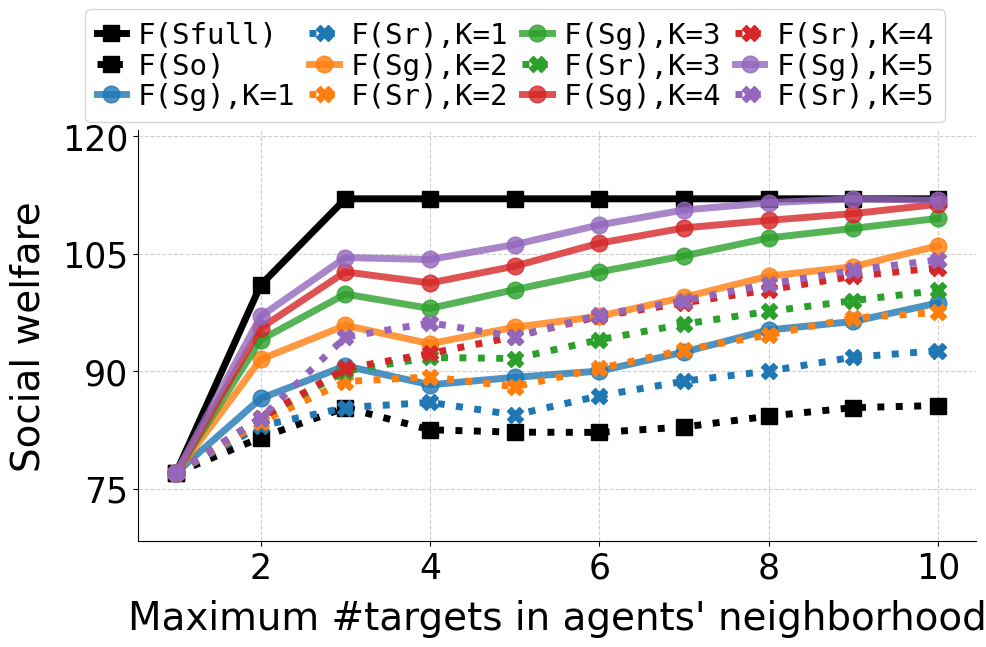

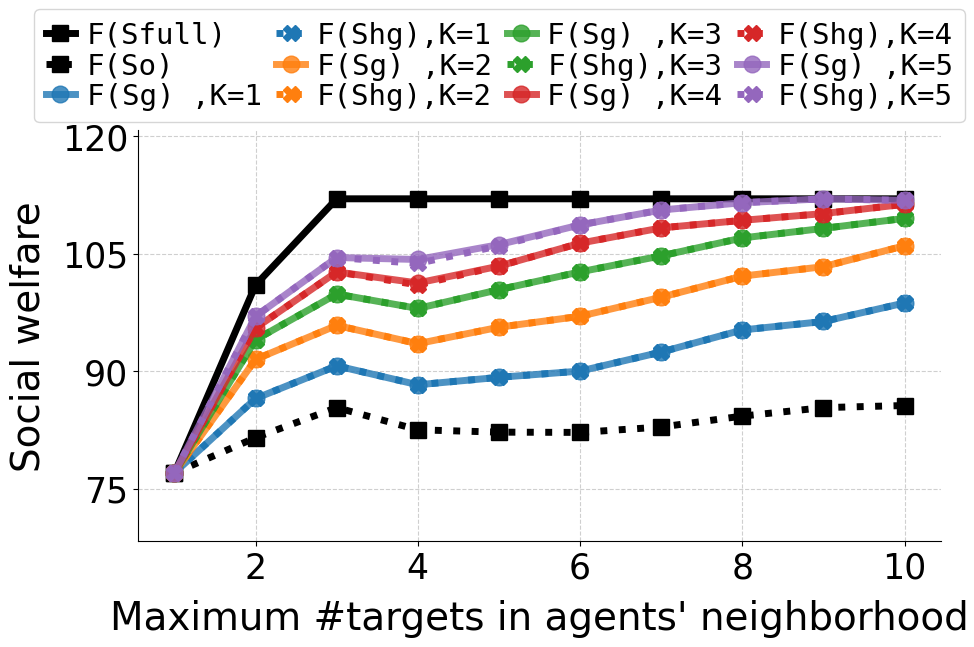

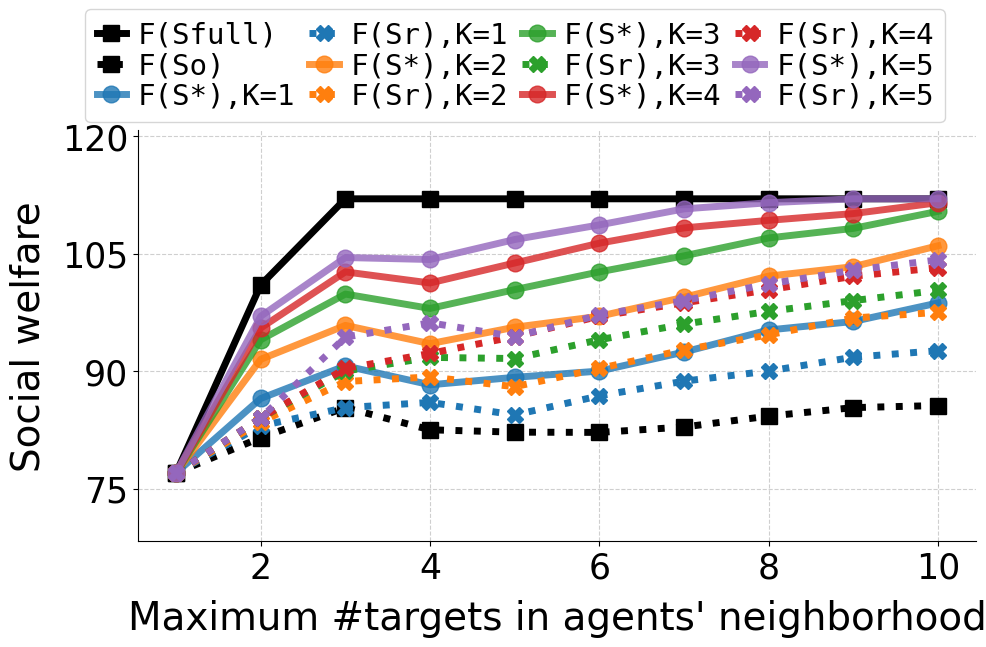

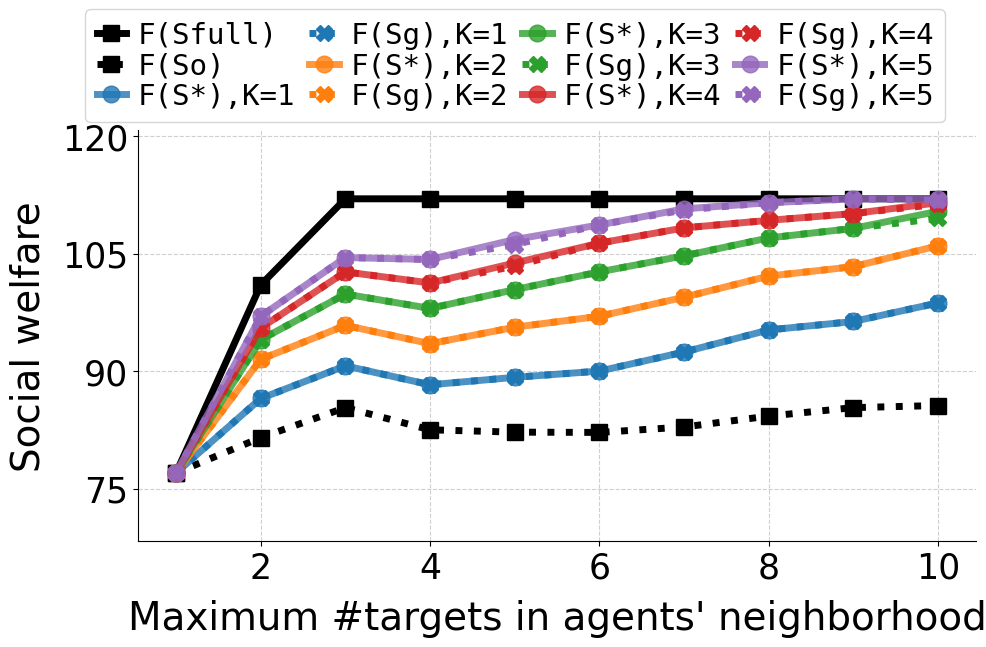

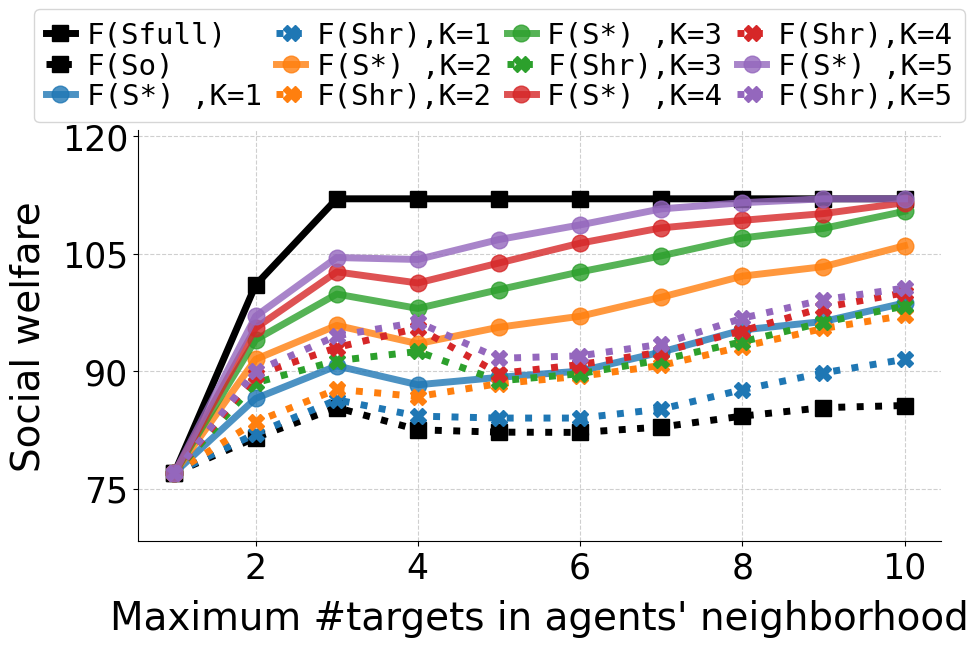

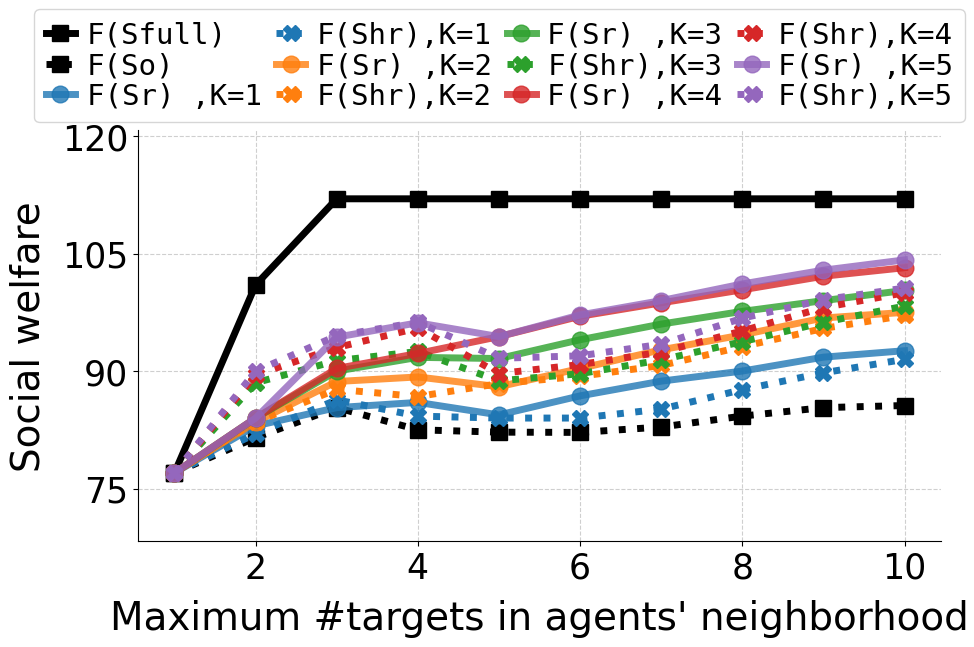

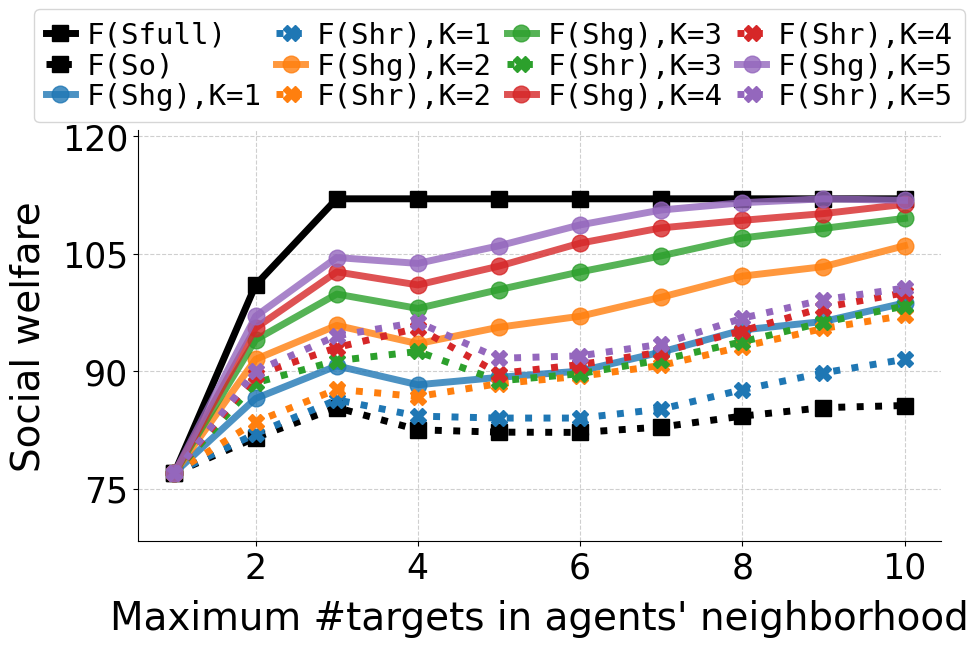

In [11]:
daz1 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",   
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_knn.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz144 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz144, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz244 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz244, x_col="kmax", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz245 = mdf[["K", "F(Sg)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz245, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
###########################
daz3 = mdf[["K", "F(Sr)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz3, x_col="kmax", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz4 = mdf[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz4, x_col="kmax", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)

    
    

## Thresholding

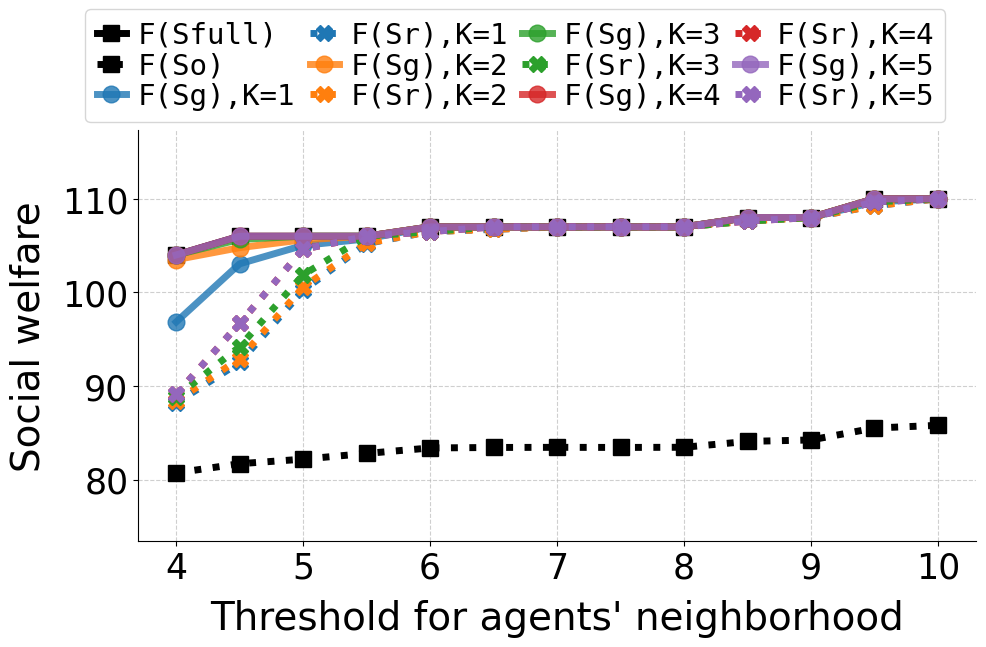

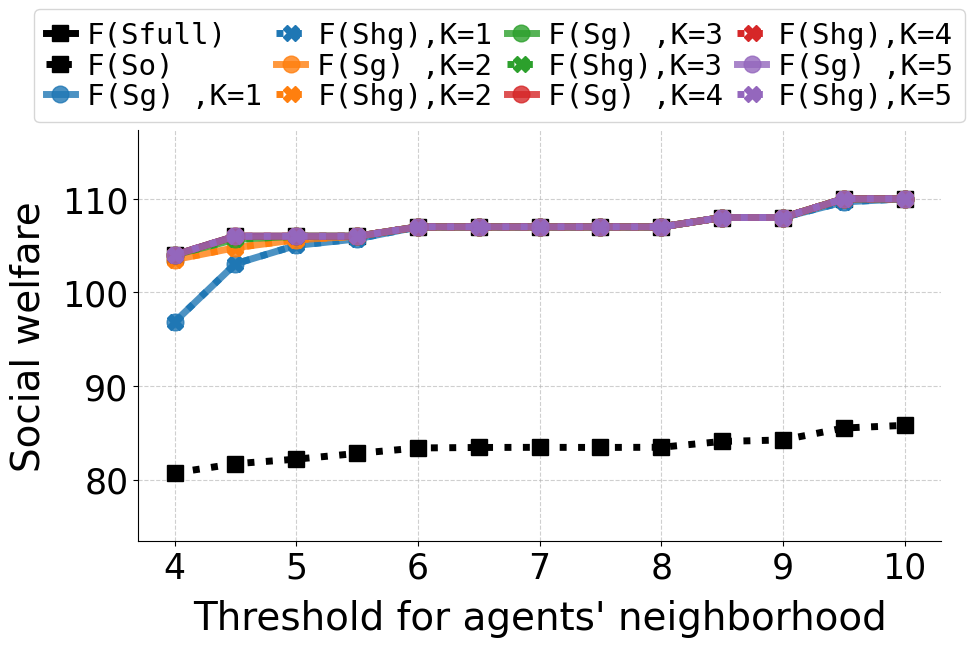

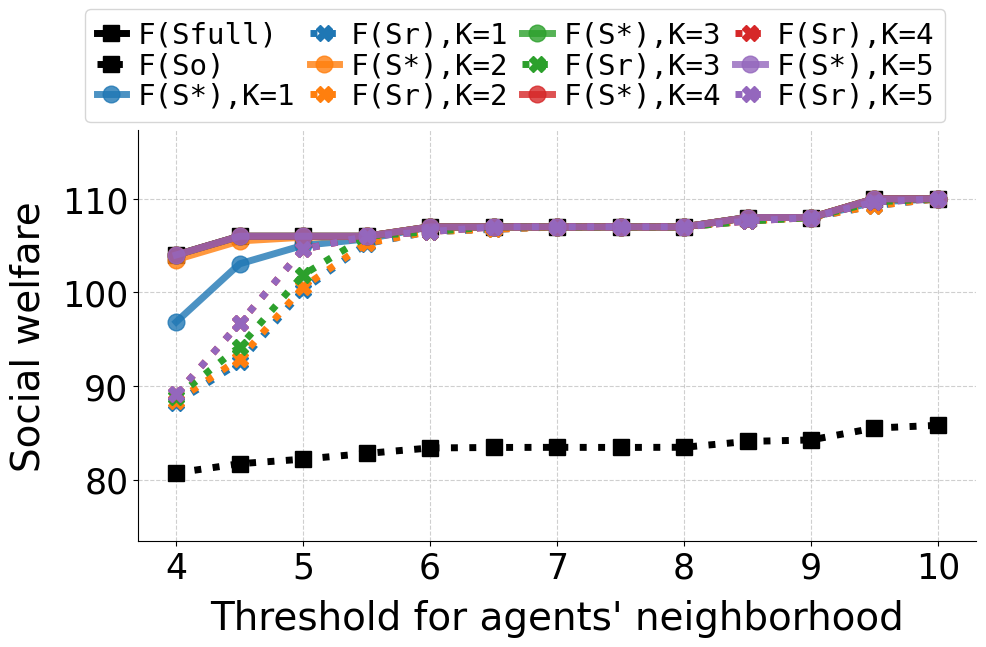

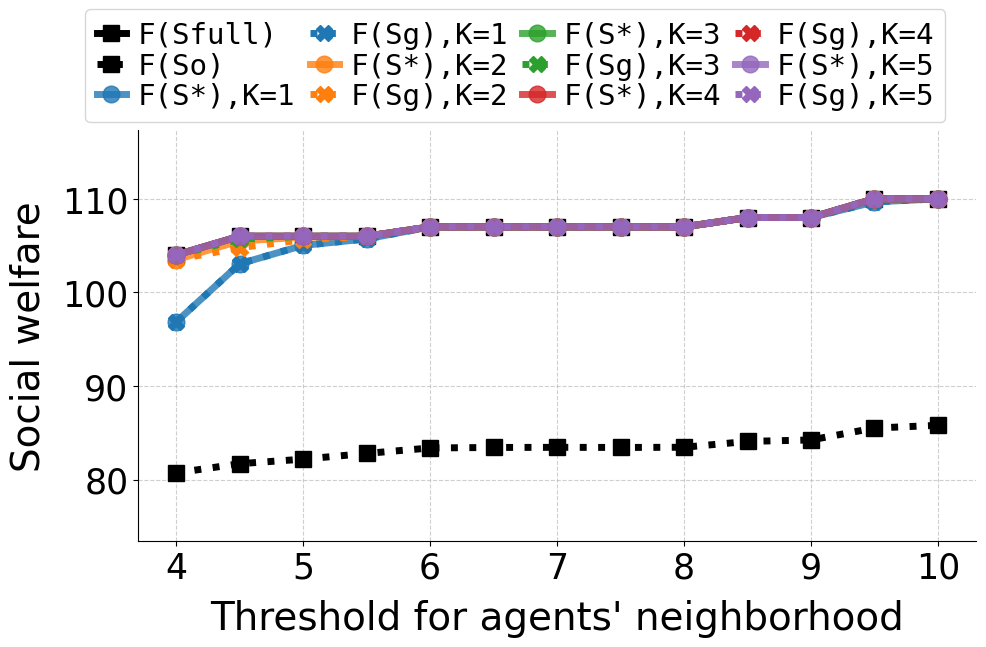

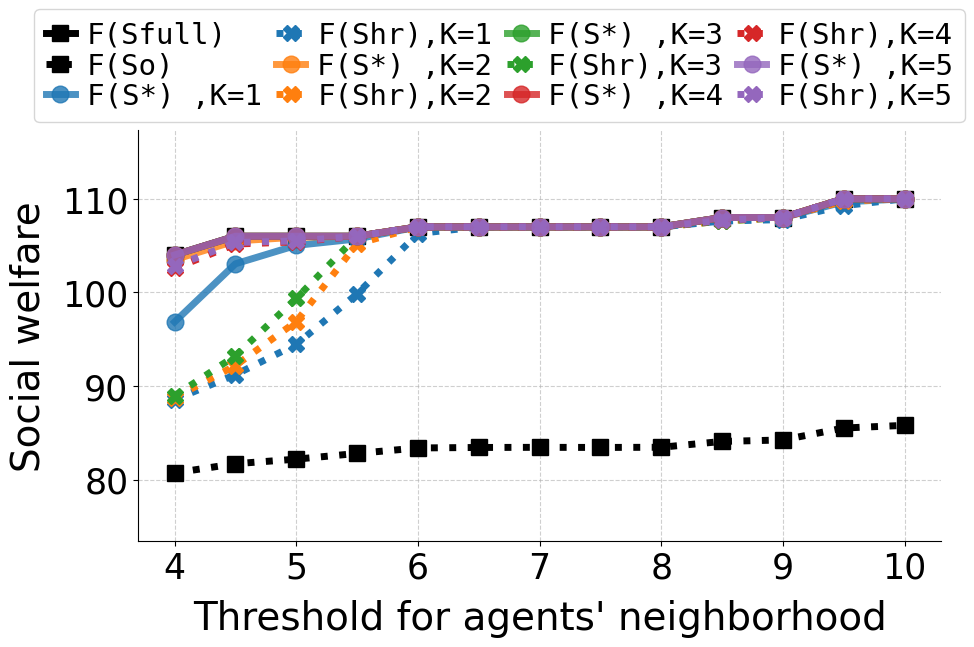

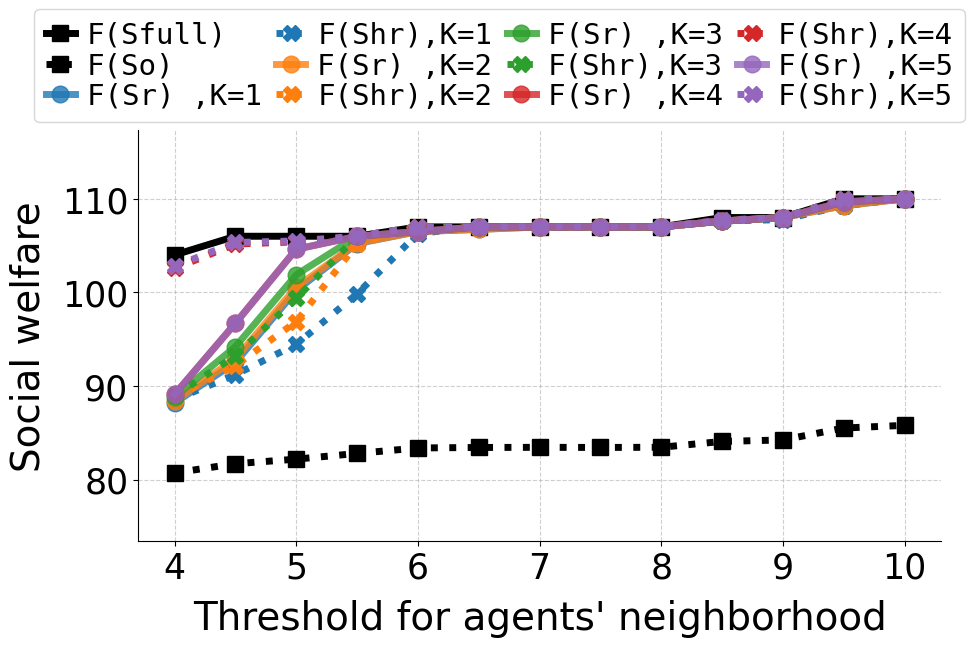

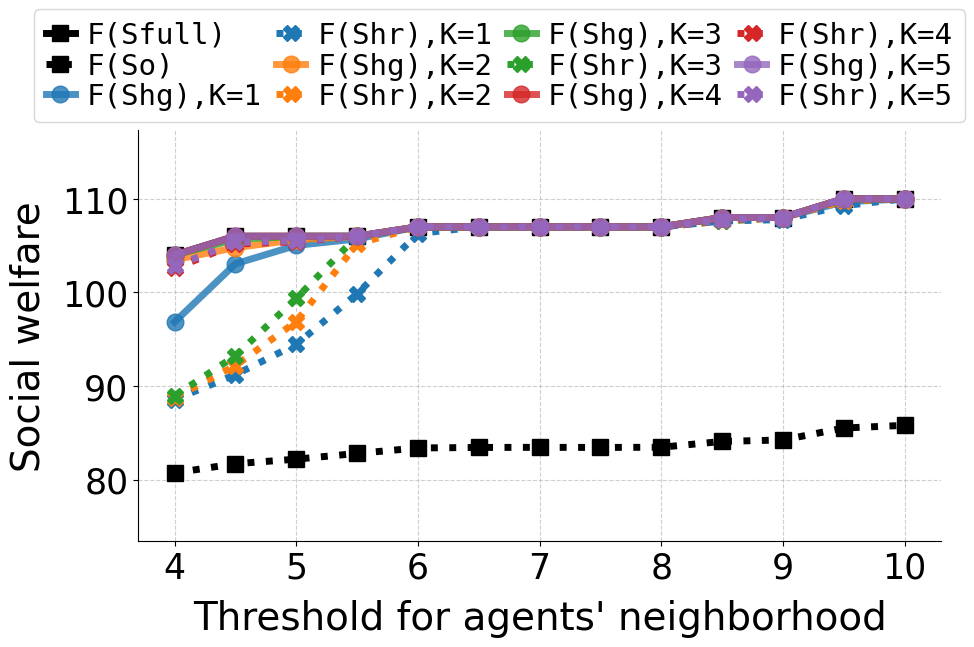

In [12]:
daz11 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz11, x_col="r", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz22 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz22, x_col="r", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz1144 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1144, x_col="r", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)",
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2244 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2244, x_col="r", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz2245 = mdfz[["K", "F(Sg)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2245, x_col="r", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz33 = mdfz[["K", "F(Sr)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz33, x_col="r", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz44 = mdfz[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz44, x_col="r", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


  